In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 1. 나눔 폰트 설치
!apt-get install -y fonts-nanum > /dev/null

# 2. 폰트 파일 경로를 맷플롯립에 직접 등록
font_path = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)

# 3. 기본 폰트 적용 및 음수 부호 설정
plt.rc("font", family=font_prop.get_name())
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
import warnings

warnings.filterwarnings('ignore')  # 경고 메시지 숨기기

In [ ]:
import pandas as pd
import requests
import json

# 1. API 접속 정보 설정 (발급받은 인증키와 API URL 입력)
API_KEY = "61A610F308ED4441A6928E878796C88F8AC1D9D6"
url = "https://data-dbg.krx.co.kr/svc/apis/esg/esg_index_info"

# 2. 조회 요청 파라미터 (특정 기준일자 지정, 예: 20260824)
# 특정 기간 데이터를 수집하려면 날짜 리스트나 반복문을 구성하여 호출해야 합니다.
headers = {
    "AUTH_KEY": API_KEY,
    "Content-Type": "application/json"
}
params = {
    "basDd": "20260824"
}

response = requests.get(url, headers=headers, params=params)

if response.status_code == 200:
    data = response.json()
    # OutBlock_1에 지수별 데이터가 리스트 형태로 반환됨
    df = pd.DataFrame(data.get("OutBlock_1", []))
    print("데이터 수집 성공! 상위 5행:")
    display(df.head())
else:
    print(f"데이터 조회 실패: {response.status_code}, 메시지: {response.text}")

# 3. 데이터셋 기본 구조 및 결측치 확인
print("\n--- 데이터프레임 정보 ---")
print(df.info())

print("\n--- 기초 통계량 (수치형 데이터) ---")
# CLSPRC_IDX(현재가), UPDN_RATE(등락률) 등이 문자열일 수 있으므로 형 변환 필요
# df['CLSPRC_IDX'] = pd.to_numeric(df['CLSPRC_IDX'].str.replace(',', ''), errors='coerce')
display(df.describe())

print("\n--- 결측치 현황 ---")
print(df.isnull().sum())

데이터 수집 성공! 상위 5행:


,BAS_DD,IDX_NM,CLSPRC_IDX,PRV_DD_CMPR,UPDN_RATE,TRD_ISU_CNT,ACC_TRDVOL,ACC_TRDVAL
0,20260824,KRX 300 기후변화지수,4456.43,-160.46,-3.48,243,149031,24835895
1,20260824,KRX ESG Leaders 150,3226.48,-.79,-.02,149,113144,21239179
2,20260824,KRX ESG 사회책임경영지수(S),7423.6,-281.72,-3.66,126,79910,19753918
3,20260824,KRX Eco Leaders 100,3616.56,30.46,.85,99,73979,4258284
4,20260824,KRX Governance Leaders 100,3565.33,14.15,.4,99,71642,4633304



--- 데이터프레임 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   BAS_DD       9 non-null      object
 1   IDX_NM       9 non-null      object
 2   CLSPRC_IDX   9 non-null      object
 3   PRV_DD_CMPR  9 non-null      object
 4   UPDN_RATE    9 non-null      object
 5   TRD_ISU_CNT  9 non-null      object
 6   ACC_TRDVOL   9 non-null      object
 7   ACC_TRDVAL   9 non-null      object
dtypes: object(8)
memory usage: 708.0+ bytes
None

--- 기초 통계량 (수치형 데이터) ---


,BAS_DD,IDX_NM,CLSPRC_IDX,PRV_DD_CMPR,UPDN_RATE,TRD_ISU_CNT,ACC_TRDVOL,ACC_TRDVAL
count,9,9,9,9,9,9,9,9
unique,1,9,9,9,9,8,9,9
top,20260824,KRX 300 기후변화지수,4456.43,-160.46,-3.48,99,149031,24835895
freq,9,1,1,1,1,2,1,1



--- 결측치 현황 ---
BAS_DD         0
IDX_NM         0
CLSPRC_IDX     0
PRV_DD_CMPR    0
UPDN_RATE      0
TRD_ISU_CNT    0
ACC_TRDVOL     0
ACC_TRDVAL     0
dtype: int64


In [ ]:
from datetime import datetime, timedelta
import json
import pandas as pd
import requests

# 1. API 접속 정보 설정 (발급받은 인증키와 코스피 지수 API URL 입력)
API_KEY = "61A610F308ED4441A6928E878796C88F8AC1D9D6"
url = "https://data-dbg.krx.co.kr/svc/apis/idx/kospi_dd_trd"

headers = {"AUTH_KEY": API_KEY, "Content-Type": "application/json"}

# 2. 조회 요청 파라미터 설정 (특정 기준일자 지정)
params = {"basDd": "20260824"}

response = requests.get(url, headers=headers, params=params)

if response.status_code == 200:
  data = response.json()
  # API 응답 구조에 맞게 블록명 지정 (일반적으로 OutBlock_1 또는 OutBlock)
  df_kospi = pd.DataFrame(data.get("OutBlock_1", []))
  print("코스피 지수 데이터 수집 성공! 상위 5행:")
  display(df_kospi.head())
else:
  print(
      f"데이터 조회 실패: {response.status_code}, 메시지: {response.text}"
  )

코스피 지수 데이터 수집 성공! 상위 5행:


""


In [ ]:
# Colab 환경 한글 폰트 설치 코드
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 4 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

# 1. 코스피 지수 데이터 추가 수집 (결측치 안전 변환 적용)
url_kospi = "https://data-dbg.krx.co.kr/svc/apis/idx/kospi_dd_trd"
kospi_data = []

for d in business_days:
  bas_dd = d.strftime("%Y%m%d")
  response = requests.get(
      url_kospi, headers=headers, params={"basDd": bas_dd}
  )
  if response.status_code == 200:
    items = response.json().get("OutBlock_1", [])
    if items:
      df_k = pd.DataFrame(items)
      kospi_data.append(df_k)

df_k_total = pd.concat(kospi_data, ignore_index=True)
df_k_total["Date"] = pd.to_datetime(df_k_total["BAS_DD"])

# 빈 문자열을 NaN으로 변환 후 숫자로 변경
df_k_total["Close"] = pd.to_numeric(
    df_k_total["CLSPRC_IDX"].astype(str).str.replace(",", "").str.strip(),
    errors="coerce",
)

# 코스피 종가 시리즈 생성
kospi_series = (
    df_k_total[df_k_total["IDX_NM"] == "코스피"]
    .set_index("Date")["Close"]
    .rename("KOSPI")
)
if kospi_series.empty:
  kospi_series = (
      df_k_total[df_k_total["IDX_NM"].str.contains("코스피", na=False)]
      .groupby("Date")["Close"]
      .first()
      .rename("KOSPI")
  )

# 기존 df_pivot과 코스피 병합
df_merged = df_pivot.join(kospi_series, how="inner").dropna()


# 2. 분석 및 시각화 함수
def run_all_esg_eda(df, bm_col="KOSPI"):
  esg_columns = [col for col in df.columns if col != bm_col]
  print(
      f"=== 총 {len(esg_columns)}개의 ESG 지수와 {bm_col} 비교 분석 시작 ==="
  )

  summary_list = []

  for esg in esg_columns:
    sub_df = df[[esg, bm_col]].dropna().copy()
    sub_df["ESG_Ret"] = sub_df[esg].pct_change()
    sub_df["BM_Ret"] = sub_df[bm_col].pct_change()
    sub_df = sub_df.dropna()

    # 상대강도 (시작점 = 100)
    sub_df["Relative_Strength"] = (
        (sub_df[esg] / sub_df[bm_col])
        / (sub_df[esg].iloc[0] / sub_df[bm_col].iloc[0])
        * 100
    )

    # 1년 롤링 초과수익률 (252영업일 기준)
    sub_df["Rolling_Excess_Ret_1Y"] = (
        sub_df["ESG_Ret"].rolling(252).mean()
        - sub_df["BM_Ret"].rolling(252).mean()
    ) * 252

    # CAPM 회귀분석
    X = sm.add_constant(sub_df["BM_Ret"])
    y = sub_df["ESG_Ret"]
    model = sm.OLS(y, X).fit()

    alpha_annual = model.params["const"] * 252
    alpha_pvalue = model.pvalues["const"]
    beta = model.params["BM_Ret"]
    r2 = model.rsquared

    summary_list.append({
        "지수명": esg,
        "CAPM Alpha(연율화)": f"{alpha_annual*100:.2f}%",
        "Alpha p-val": f"{alpha_pvalue:.4f}",
        "Beta": f"{beta:.3f}",
        "R-squared": f"{r2:.3f}",
    })

    # 시각화
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"[{esg}] vs KOSPI EDA 분석", fontsize=14, fontweight="bold")

    axes[0].plot(
        sub_df.index,
        sub_df["Relative_Strength"],
        color="tab:blue",
        lw=1.5,
        label="상대강도",
    )
    axes[0].axhline(100, color="red", linestyle=":", alpha=0.7, label="기준선 100")
    axes[0].set_title("상대강도 차트 (100선 기준)")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(
        sub_df.index,
        sub_df["Rolling_Excess_Ret_1Y"] * 100,
        color="tab:purple",
        lw=1.2,
    )
    axes[1].axhline(0, color="black", linestyle="-", alpha=0.5)
    axes[1].set_title("1년 롤링 초과수익률 (%)")
    axes[1].grid(True, alpha=0.3)

    axes[2].scatter(
        sub_df["BM_Ret"] * 100,
        sub_df["ESG_Ret"] * 100,
        alpha=0.2,
        color="gray",
        s=10,
    )
    bm_range = np.linspace(sub_df["BM_Ret"].min(), sub_df["BM_Ret"].max(), 100)
    pred_y = (model.params["const"] + beta * bm_range) * 100
    axes[2].plot(
        bm_range * 100,
        pred_y,
        color="red",
        lw=1.5,
        label=f"Beta: {beta:.2f}, Alpha: {alpha_annual*100:.2f}%",
    )
    axes[2].set_xlabel("KOSPI 수익률 (%)")
    axes[2].set_ylabel("ESG 수익률 (%)")
    axes[2].set_title("CAPM 회귀선")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

  display(pd.DataFrame(summary_list))


run_all_esg_eda(df_merged)

NameError: name 'business_days' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm

# 1. API 접속 정보 설정
API_KEY = "61A610F308ED4441A6928E878796C88F8AC1D9D6"
headers = {"AUTH_KEY": API_KEY, "Content-Type": "application/json"}

start_date = "2023-01-01"
end_date = "2025-12-31"
business_days = pd.date_range(start=start_date, end=end_date, freq="B")

esg_data = []
kospi200_data = []

print("데이터 수집 중...")

# 2. 영업일별 데이터 일괄 수집
for d in business_days:
  bas_dd = d.strftime("%Y%m%d")

  # A. ESG 지수들 수집
  res_esg = requests.get(
      "https://data-dbg.krx.co.kr/svc/apis/esg/esg_index_info",
      headers=headers,
      params={"basDd": bas_dd},
  )
  if res_esg.status_code == 200:
    items = res_esg.json().get("OutBlock_1", [])
    if items:
      df_temp = pd.DataFrame(items)
      df_temp["Date"] = pd.to_datetime(bas_dd)
      esg_data.append(df_temp)

  # B. 일반 지수(코스피 200 포함) 수집
  res_idx = requests.get(
      "https://data-dbg.krx.co.kr/svc/apis/idx/kospi_dd_trd",
      headers=headers,
      params={"basDd": bas_dd},
  )
  if res_idx.status_code == 200:
    items_idx = res_idx.json().get("OutBlock_1", [])
    if items_idx:
      df_idx_temp = pd.DataFrame(items_idx)
      df_idx_temp["Date"] = pd.to_datetime(bas_dd)
      kospi200_data.append(df_idx_temp)

# 3. 데이터프레임 병합 및 정제
df_esg_total = pd.concat(esg_data, ignore_index=True)
df_esg_total["Close"] = pd.to_numeric(
    df_esg_total["CLSPRC_IDX"].astype(str).str.replace(",", "").str.strip(),
    errors="coerce",
)

df_idx_total = pd.concat(kospi200_data, ignore_index=True)
df_idx_total["Close"] = pd.to_numeric(
    df_idx_total["CLSPRC_IDX"].astype(str).str.replace(",", "").str.strip(),
    errors="coerce",
)

# 대상 지수 추출 ('코스피 200' 과 '코스피 200 ESG 지수')
target_esg = "코스피 200 ESG 지수"
esg_series = (
    df_esg_total[df_esg_total["IDX_NM"] == target_esg]
    .set_index("Date")["Close"]
    .rename("ESG_200")
)

bm_series = (
    df_idx_total[df_idx_total["IDX_NM"] == "코스피 200"]
    .set_index("Date")["Close"]
    .rename("KOSPI_200")
)

# 두 시리즈 병합
sub_df = pd.concat([esg_series, bm_series], axis=1).dropna()

# 4. 수익률 및 EDA 계산
sub_df["ESG_Ret"] = sub_df["ESG_200"].pct_change()
sub_df["BM_Ret"] = sub_df["KOSPI_200"].pct_change()
sub_df = sub_df.dropna()

# 상대강도 (시작점 = 100)
sub_df["Relative_Strength"] = (
    (sub_df["ESG_200"] / sub_df["KOSPI_200"])
    / (sub_df["ESG_200"].iloc[0] / sub_df["KOSPI_200"].iloc[0])
    * 100
)

# 1년 롤링 초과수익률
sub_df["Rolling_Excess_Ret_1Y"] = (
    sub_df["ESG_Ret"].rolling(252).mean() - sub_df["BM_Ret"].rolling(252).mean()
) * 252

# CAPM 회귀분석
X = sm.add_constant(sub_df["BM_Ret"])
y = sub_df["ESG_Ret"]
model = sm.OLS(y, X).fit()

alpha_annual = model.params["const"] * 252
alpha_pvalue = model.pvalues["const"]
beta = model.params["BM_Ret"]
r2 = model.rsquared

print(f"=== [{target_esg}] vs [코스피 200] 분석 결과 ===")
print(f"CAPM 연율화 Alpha: {alpha_annual*100:.2f}% (p-val: {alpha_pvalue:.4f})")
print(f"Beta: {beta:.3f} | R-squared: {r2:.3f}")

# 5. 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle(
    f"[{target_esg}] vs KOSPI 200 정밀 EDA 분석",
    fontsize=14,
    fontweight="bold",
)

# 상대강도
axes[0].plot(
    sub_df.index,
    sub_df["Relative_Strength"],
    color="tab:blue",
    lw=1.5,
    label="상대강도",
)
axes[0].axhline(100, color="red", linestyle=":", alpha=0.7, label="기준선 100")
axes[0].set_title("상대강도 차트 (100선 기준)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 롤링 초과수익률
axes[1].plot(
    sub_df.index,
    sub_df["Rolling_Excess_Ret_1Y"] * 100,
    color="tab:purple",
    lw=1.2,
)
axes[1].axhline(0, color="black", linestyle="-", alpha=0.5)
axes[1].set_title("1년 롤링 초과수익률 (%)")
axes[1].grid(True, alpha=0.3)

# CAPM 산포도 및 회귀선
axes[2].scatter(
    sub_df["BM_Ret"] * 100,
    sub_df["ESG_Ret"] * 100,
    alpha=0.2,
    color="gray",
    s=10,
)
bm_range = np.linspace(sub_df["BM_Ret"].min(), sub_df["BM_Ret"].max(), 100)
pred_y = (model.params["const"] + beta * bm_range) * 100
axes[2].plot(
    bm_range * 100,
    pred_y,
    color="red",
    lw=1.5,
    label=f"Beta: {beta:.2f}, Alpha: {alpha_annual*100:.2f}%",
)
axes[2].set_xlabel("KOSPI 200 수익률 (%)")
axes[2].set_ylabel("ESG 200 수익률 (%)")
axes[2].set_title("CAPM 회귀선")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm

# 1. API 접속 정보 설정
API_KEY = "61A610F308ED4441A6928E878796C88F8AC1D9D6"
headers = {"AUTH_KEY": API_KEY, "Content-Type": "application/json"}

# 3년치 기간 설정
start_date = "2023-01-01"
end_date = "2025-12-31"
business_days = pd.date_range(start=start_date, end=end_date, freq="B")

esg_data = []
kospi200_data = []

print("3년치 데이터 수집 중...")

# 2. 영업일별 데이터 일괄 수집
for d in business_days:
  bas_dd = d.strftime("%Y%m%d")

  # A. ESG 지수들 수집
  res_esg = requests.get(
      "https://data-dbg.krx.co.kr/svc/apis/esg/esg_index_info",
      headers=headers,
      params={"basDd": bas_dd},
  )
  if res_esg.status_code == 200:
    items = res_esg.json().get("OutBlock_1", [])
    if items:
      df_temp = pd.DataFrame(items)
      df_temp["Date"] = pd.to_datetime(bas_dd)
      esg_data.append(df_temp)

  # B. 코스피 200 포함 일반 지수 수집
  res_idx = requests.get(
      "https://data-dbg.krx.co.kr/svc/apis/idx/kospi_dd_trd",
      headers=headers,
      params={"basDd": bas_dd},
  )
  if res_idx.status_code == 200:
    items_idx = res_idx.json().get("OutBlock_1", [])
    if items_idx:
      df_idx_temp = pd.DataFrame(items_idx)
      df_idx_temp["Date"] = pd.to_datetime(bas_dd)
      kospi200_data.append(df_idx_temp)

# 3. 데이터프레임 병합 및 정제
df_esg_total = pd.concat(esg_data, ignore_index=True)
df_esg_total["Close"] = pd.to_numeric(
    df_esg_total["CLSPRC_IDX"].astype(str).str.replace(",", "").str.strip(),
    errors="coerce",
)

df_idx_total = pd.concat(kospi200_data, ignore_index=True)
df_idx_total["Close"] = pd.to_numeric(
    df_idx_total["CLSPRC_IDX"].astype(str).str.replace(",", "").str.strip(),
    errors="coerce",
)

target_esg = "코스피 200 ESG 지수"
esg_series = (
    df_esg_total[df_esg_total["IDX_NM"] == target_esg]
    .set_index("Date")["Close"]
    .rename("ESG_200")
)

bm_series = (
    df_idx_total[df_idx_total["IDX_NM"] == "코스피 200"]
    .set_index("Date")["Close"]
    .rename("KOSPI_200")
)

sub_df = pd.concat([esg_series, bm_series], axis=1).dropna()

# 4. 수익률 및 통계 연산
sub_df["ESG_Ret"] = sub_df["ESG_200"].pct_change()
sub_df["BM_Ret"] = sub_df["KOSPI_200"].pct_change()
sub_df = sub_df.dropna()

# 상대강도 (시작점 = 100)
sub_df["Relative_Strength"] = (
    (sub_df["ESG_200"] / sub_df["KOSPI_200"])
    / (sub_df["ESG_200"].iloc[0] / sub_df["KOSPI_200"].iloc[0])
    * 100
)

# 1년 롤링 초과수익률
sub_df["Rolling_Excess_Ret_1Y"] = (
    sub_df["ESG_Ret"].rolling(252).mean() - sub_df["BM_Ret"].rolling(252).mean()
) * 252

# CAPM 회귀분석
X = sm.add_constant(sub_df["BM_Ret"])
y = sub_df["ESG_Ret"]
model = sm.OLS(y, X).fit()

alpha_annual = model.params["const"] * 252
alpha_pvalue = model.pvalues["const"]
beta = model.params["BM_Ret"]
r2 = model.rsquared

# 5. 통계 요약 표 출력
summary_df = pd.DataFrame([{
    "비교 지수": target_esg,
    "연율화 Alpha": f"{alpha_annual*100:.2f}%",
    "Alpha p-val": f"{alpha_pvalue:.4f}",
    "Beta": f"{beta:.3f}",
    "R-squared": f"{r2:.3f}",
}])

print(f"\n=== [{target_esg}] vs [코스피 200] 3년치 통계량 검증 결과 ===")
display(summary_df)

# 6. 시각화 (1x3 서브플롯)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle(
    f"[{target_esg}] vs KOSPI 200 (3년치 EDA 및 팩터 검증)",
    fontsize=14,
    fontweight="bold",
)

# 상대강도
axes[0].plot(
    sub_df.index,
    sub_df["Relative_Strength"],
    color="tab:blue",
    lw=1.5,
    label="상대강도",
)
axes[0].axhline(100, color="red", linestyle=":", alpha=0.7, label="기준선 100")
axes[0].set_title("상대강도 차트 (100선 기준)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 롤링 초과수익률
axes[1].plot(
    sub_df.index,
    sub_df["Rolling_Excess_Ret_1Y"] * 100,
    color="tab:purple",
    lw=1.2,
)
axes[1].axhline(0, color="black", linestyle="-", alpha=0.5)
axes[1].set_title("1년 롤링 초과수익률 (%)")
axes[1].grid(True, alpha=0.3)

# CAPM 회귀선
axes[2].scatter(
    sub_df["BM_Ret"] * 100,
    sub_df["ESG_Ret"] * 100,
    alpha=0.2,
    color="gray",
    s=10,
)
bm_range = np.linspace(sub_df["BM_Ret"].min(), sub_df["BM_Ret"].max(), 100)
pred_y = (model.params["const"] + beta * bm_range) * 100
axes[2].plot(
    bm_range * 100,
    pred_y,
    color="red",
    lw=1.5,
    label=f"Beta: {beta:.2f}, Alpha: {alpha_annual*100:.2f}%",
)
axes[2].set_xlabel("KOSPI 200 수익률 (%)")
axes[2].set_ylabel("ESG 200 수익률 (%)")
axes[2].set_title("CAPM 회귀선")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

총 783영업일 데이터 안전 수집 시작...

=== [코스피 200 ESG 지수] vs [코스피 200] 3년치 분석 결과 ===


,비교 지수,연율화 Alpha,Alpha p-val,Beta,R-squared
0,코스피 200 ESG 지수,3.80%,0.1845,1.006,0.947


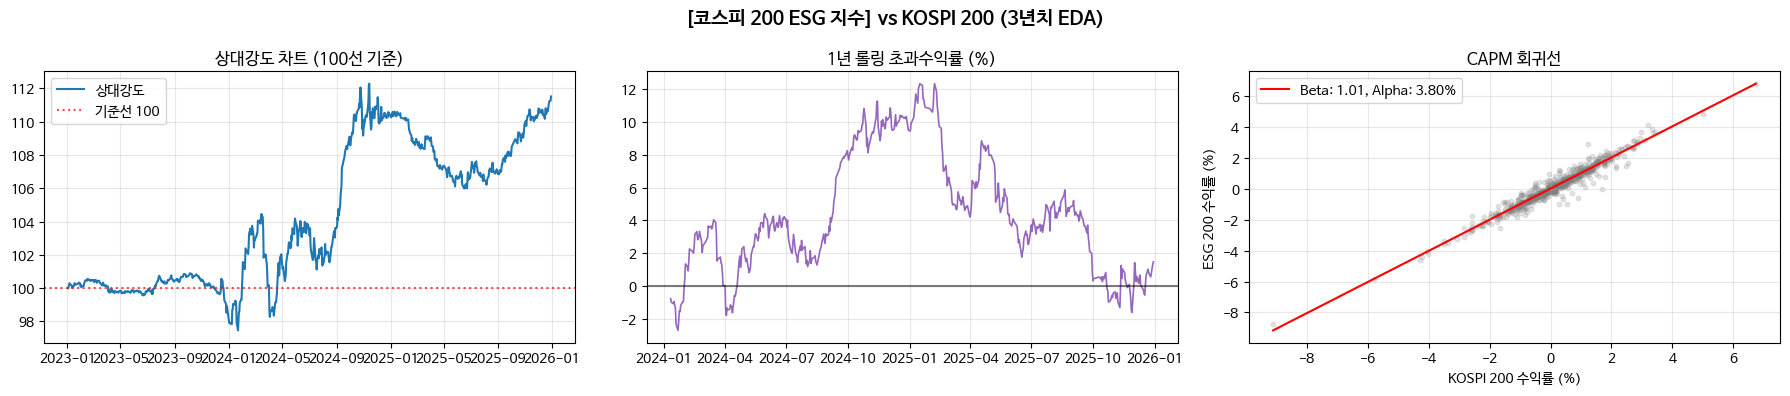

In [ ]:
import time
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm

# 1. 폰트 직접 등록 (경고 및 깨짐 방지)
font_path = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rc("font", family=font_prop.get_name())
plt.rcParams["axes.unicode_minus"] = False

# 2. API 설정 및 기간 정의 (3년치)
API_KEY = "61A610F308ED4441A6928E878796C88F8AC1D9D6"
headers = {"AUTH_KEY": API_KEY, "Content-Type": "application/json"}

start_date = "2023-01-01"
end_date = "2025-12-31"
business_days = pd.date_range(start=start_date, end=end_date, freq="B")

esg_data = []
kospi200_data = []

print(f"총 {len(business_days)}영업일 데이터 안전 수집 시작...")

# 3. 데이터 수집 (예외 처리 포함)
for d in business_days:
  bas_dd = d.strftime("%Y%m%d")

  # ESG 지수 수집
  try:
    res_esg = requests.get(
        "https://data-dbg.krx.co.kr/svc/apis/esg/esg_index_info",
        headers=headers,
        params={"basDd": bas_dd},
        timeout=5,
    )
    if res_esg.status_code == 200:
      items = res_esg.json().get("OutBlock_1", [])
      if items:
        df_temp = pd.DataFrame(items)
        df_temp["Date"] = pd.to_datetime(bas_dd)
        esg_data.append(df_temp)
  except Exception:
    pass

  # 코스피 200 지수 수집
  try:
    res_idx = requests.get(
        "https://data-dbg.krx.co.kr/svc/apis/idx/kospi_dd_trd",
        headers=headers,
        params={"basDd": bas_dd},
        timeout=5,
    )
    if res_idx.status_code == 200:
      items_idx = res_idx.json().get("OutBlock_1", [])
      if items_idx:
        df_idx_temp = pd.DataFrame(items_idx)
        df_idx_temp["Date"] = pd.to_datetime(bas_dd)
        kospi200_data.append(df_idx_temp)
  except Exception:
    pass

  time.sleep(0.02)

# 4. 데이터프레임 병합 및 정제
df_esg_total = pd.concat(esg_data, ignore_index=True)
df_esg_total["Close"] = pd.to_numeric(
    df_esg_total["CLSPRC_IDX"].astype(str).str.replace(",", "").str.strip(),
    errors="coerce",
)

df_idx_total = pd.concat(kospi200_data, ignore_index=True)
df_idx_total["Close"] = pd.to_numeric(
    df_idx_total["CLSPRC_IDX"].astype(str).str.replace(",", "").str.strip(),
    errors="coerce",
)

target_esg = "코스피 200 ESG 지수"
esg_series = (
    df_esg_total[df_esg_total["IDX_NM"] == target_esg]
    .set_index("Date")["Close"]
    .rename("ESG_200")
)
bm_series = (
    df_idx_total[df_idx_total["IDX_NM"] == "코스피 200"]
    .set_index("Date")["Close"]
    .rename("KOSPI_200")
)

sub_df = pd.concat([esg_series, bm_series], axis=1).dropna()

# 5. 수익률 및 CAPM 통계 연산
sub_df["ESG_Ret"] = sub_df["ESG_200"].pct_change()
sub_df["BM_Ret"] = sub_df["KOSPI_200"].pct_change()
sub_df = sub_df.dropna()

sub_df["Relative_Strength"] = (
    (sub_df["ESG_200"] / sub_df["KOSPI_200"])
    / (sub_df["ESG_200"].iloc[0] / sub_df["KOSPI_200"].iloc[0])
    * 100
)
sub_df["Rolling_Excess_Ret_1Y"] = (
    sub_df["ESG_Ret"].rolling(252).mean() - sub_df["BM_Ret"].rolling(252).mean()
) * 252

X = sm.add_constant(sub_df["BM_Ret"])
y = sub_df["ESG_Ret"]
model = sm.OLS(y, X).fit()

alpha_annual = model.params["const"] * 252
alpha_pvalue = model.pvalues["const"]
beta = model.params["BM_Ret"]
r2 = model.rsquared

# 6. 통계 요약 표 출력
summary_df = pd.DataFrame([{
    "비교 지수": target_esg,
    "연율화 Alpha": f"{alpha_annual*100:.2f}%",
    "Alpha p-val": f"{alpha_pvalue:.4f}",
    "Beta": f"{beta:.3f}",
    "R-squared": f"{r2:.3f}",
}])

print(f"\n=== [{target_esg}] vs [코스피 200] 3년치 분석 결과 ===")
display(summary_df)

# 7. 3종 시각화 그래프
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle(
    f"[{target_esg}] vs KOSPI 200 (3년치 EDA)", fontsize=14, fontweight="bold"
)

# 상대강도
axes[0].plot(
    sub_df.index,
    sub_df["Relative_Strength"],
    color="tab:blue",
    lw=1.5,
    label="상대강도",
)
axes[0].axhline(100, color="red", linestyle=":", alpha=0.7, label="기준선 100")
axes[0].set_title("상대강도 차트 (100선 기준)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 1년 롤링 초과수익률
axes[1].plot(
    sub_df.index,
    sub_df["Rolling_Excess_Ret_1Y"] * 100,
    color="tab:purple",
    lw=1.2,
)
axes[1].axhline(0, color="black", linestyle="-", alpha=0.5)
axes[1].set_title("1년 롤링 초과수익률 (%)")
axes[1].grid(True, alpha=0.3)

# CAPM 회귀선
axes[2].scatter(
    sub_df["BM_Ret"] * 100,
    sub_df["ESG_Ret"] * 100,
    alpha=0.2,
    color="gray",
    s=10,
)
bm_range = np.linspace(sub_df["BM_Ret"].min(), sub_df["BM_Ret"].max(), 100)
pred_y = (model.params["const"] + beta * bm_range) * 100
axes[2].plot(
    bm_range * 100,
    pred_y,
    color="red",
    lw=1.5,
    label=f"Beta: {beta:.2f}, Alpha: {alpha_annual*100:.2f}%",
)
axes[2].set_xlabel("KOSPI 200 수익률 (%)")
axes[2].set_ylabel("ESG 200 수익률 (%)")
axes[2].set_title("CAPM 회귀선")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()